# Feature Engineering — AI4I 2020 Predictive Maintenance

## Objective

Create physically meaningful features from the legitimate machine inputs and verify
that the resulting feature set is leakage-safe.

This notebook does **not** train machine-learning models.

### Legitimate inputs
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

### Excluded from ML features
- UDI
- Product ID
- TWF
- HDF
- PWF
- OSF
- RNF
- Machine failure (target)

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Define raw and excluded variables

The feature policy is deliberately explicit so that the later modeling notebooks
cannot accidentally use identifiers or outcome-derived failure-mode indicators.

In [14]:
raw_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

numeric_raw_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

forbidden_features = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
    "Machine failure"
]

target = "Machine failure"

print("Raw features:", raw_features)
print("Forbidden from ML:", forbidden_features)
print("Target:", target)

Raw features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Forbidden from ML: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']
Target: Machine failure


## 2. Temperature difference

`temp_diff` is the process temperature minus the air temperature.

This is a physically meaningful representation because the documented HDF mechanism
uses the temperature difference directly.

In [15]:
df["temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

expected = df["Process temperature [K]"] - df["Air temperature [K]"]

print("Calculation correct:", np.allclose(df["temp_diff"], expected))
df[["Air temperature [K]", "Process temperature [K]", "temp_diff"]].head()

Calculation correct: True


,Air temperature [K],Process temperature [K],temp_diff
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


## 3. Mechanical power

Mechanical power is:

**Power = Torque × angular velocity**

with:

**angular velocity = RPM × 2π / 60**

This produces power in watts.

In [16]:
df["power_w"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2 * np.pi / 60
)

expected = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2 * np.pi / 60
)

print("Calculation correct:", np.allclose(df["power_w"], expected))
df[["Rotational speed [rpm]", "Torque [Nm]", "power_w"]].head()

Calculation correct: True


,Rotational speed [rpm],Torque [Nm],power_w
0,1551,42.8,6951.590560
1,1408,46.3,6826.722724
2,1498,49.4,7749.387543
3,1433,39.5,5927.504659
4,1408,40.0,5897.816608


## 4. Wear × torque

The documented OSF mechanism uses the product of tool wear and torque.

In [17]:
df["wear_torque"] = (
    df["Tool wear [min]"]
    * df["Torque [Nm]"]
)

expected = df["Tool wear [min]"] * df["Torque [Nm]"]

print("Calculation correct:", np.allclose(df["wear_torque"], expected))
df[["Tool wear [min]", "Torque [Nm]", "wear_torque"]].head()

Calculation correct: True


,Tool wear [min],Torque [Nm],wear_torque
0,0,42.8,0.0
1,3,46.3,138.9
2,5,49.4,247.0
3,7,39.5,276.5
4,9,40.0,360.0


## 5. Type-specific strain ratio

The documented OSF mechanism has different thresholds by Type.

We normalize `wear_torque` by the corresponding threshold.

In [18]:
strain_limits = {
    "L": 11000,
    "M": 12000,
    "H": 13000
}

df["strain_limit"] = df["Type"].map(strain_limits)

df["strain_ratio"] = (
    df["wear_torque"] / df["strain_limit"]
)

df[
    ["Type", "wear_torque", "strain_limit", "strain_ratio"]
].head()

,Type,wear_torque,strain_limit,strain_ratio
0,M,0.0,12000,0.000000
1,L,138.9,11000,0.012627
2,L,247.0,11000,0.022455
3,L,276.5,11000,0.025136
4,L,360.0,11000,0.032727


## 6. Engineered-feature summary

In [19]:
engineered_features = [
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temp_diff,10000.0,10.000630,1.001094,7.60000,9.300000,9.800000,11.000000,12.100000
power_w,10000.0,6279.744953,1067.418295,1148.44061,5561.184484,6271.027344,7003.002724,10469.923005
wear_torque,10000.0,4314.664550,2826.567692,0.00000,1963.650000,4012.950000,6279.000000,16497.000000
strain_ratio,10000.0,0.376537,0.248387,0.00000,0.171343,0.351027,0.549837,1.374750


## 7. Compare engineered features between normal and failed cases

This is exploratory evidence only. Differences between groups do not by themselves
establish causation.

In [20]:
comparison = (
    df.groupby(target)[engineered_features]
      .agg(["mean", "median", "std"])
      .T
)

comparison

Machine failure                0            1
temp_diff    mean      10.021571     9.403835
             median     9.800000     9.300000
             std        0.988422     1.164445
power_w      mean    6244.547534  7282.819485
             median  6243.046225  7611.429737
             std     1011.394393  1851.137977
wear_torque  mean    4213.842708  7187.938348
             median  3952.800000  7681.800000
             std     2709.744211  4234.039961
strain_ratio mean       0.367443     0.635693
             median     0.345967     0.652273
             std        0.237478     0.378994

## 8. Failure-rate relationship with engineered features

In [21]:
df["temp_diff_bin"] = pd.cut(df["temp_diff"], bins=6)
df["power_bin"] = pd.cut(df["power_w"], bins=6)
df["wear_torque_bin"] = pd.cut(df["wear_torque"], bins=6)
df["strain_ratio_bin"] = pd.cut(
    df["strain_ratio"],
    bins=[0, 0.5, 0.75, 1.0, 1.25, 1.5, np.inf]
)

def failure_rate_by_bin(data, bin_col):
    out = (
        data.groupby(bin_col, observed=True)[target]
             .agg(["count", "sum", "mean"])
             .rename(columns={"sum": "failures", "mean": "failure_rate"})
    )
    out["failure_rate"] *= 100
    return out

temp_failure = failure_rate_by_bin(df, "temp_diff_bin")
power_failure = failure_rate_by_bin(df, "power_bin")
wear_torque_failure = failure_rate_by_bin(df, "wear_torque_bin")
strain_ratio_failure = failure_rate_by_bin(df, "strain_ratio_bin")

print("Temperature difference")
display(temp_failure)

print("Power")
display(power_failure)

print("Wear × torque")
display(wear_torque_failure)

print("Strain ratio")
display(strain_ratio_failure)

Temperature difference


,count,failures,failure_rate
temp_diff_bin,,,
"(7.595, 8.35]",459,71,15.468410
"(8.35, 9.1]",1438,86,5.980529
"(9.1, 9.85]",3167,71,2.241869
"(9.85, 10.6]",1344,30,2.232143
"(10.6, 11.35]",2778,67,2.411807
"(11.35, 12.1]",814,14,1.719902


Power


,count,failures,failure_rate
power_bin,,,
"(1139.119, 2702.021]",8,8,100.000000
"(2702.021, 4255.601]",284,26,9.154930
"(4255.601, 5809.182]",2980,19,0.637584
"(5809.182, 7362.762]",5179,96,1.853640
"(7362.762, 8916.343]",1471,122,8.293678
"(8916.343, 10469.923]",78,68,87.179487


Wear × torque


,count,failures,failure_rate
wear_torque_bin,,,
"(-16.497, 2749.5]",3438,72,2.094241
"(2749.5, 5499.0]",3231,53,1.640359
"(5499.0, 8248.5]",2311,59,2.553007
"(8248.5, 10998.0]",895,53,5.921788
"(10998.0, 13747.5]",119,96,80.672269
"(13747.5, 16497.0]",6,6,100.000000


Strain ratio


,count,failures,failure_rate
strain_ratio_bin,,,
"(0.0, 0.5]",6811,128,1.879313
"(0.5, 0.75]",2219,62,2.794051
"(0.75, 1.0]",752,48,6.382979
"(1.0, 1.25]",94,94,100.000000
"(1.25, 1.5]",4,4,100.000000


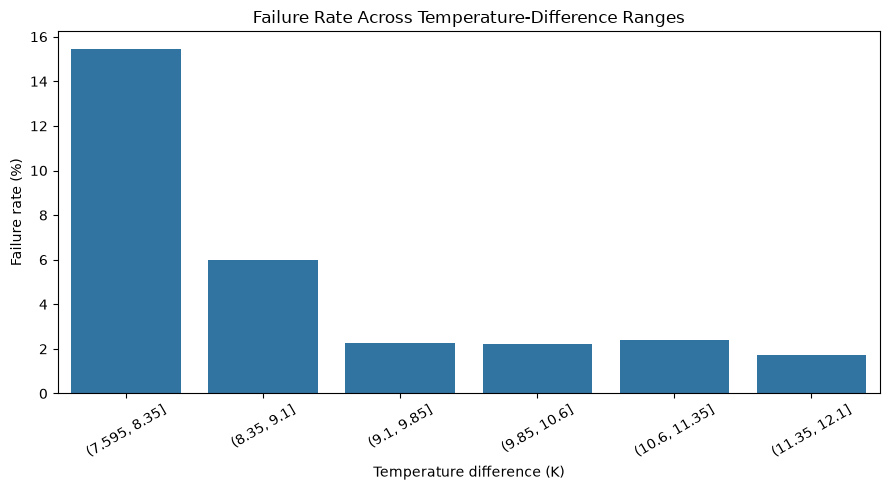

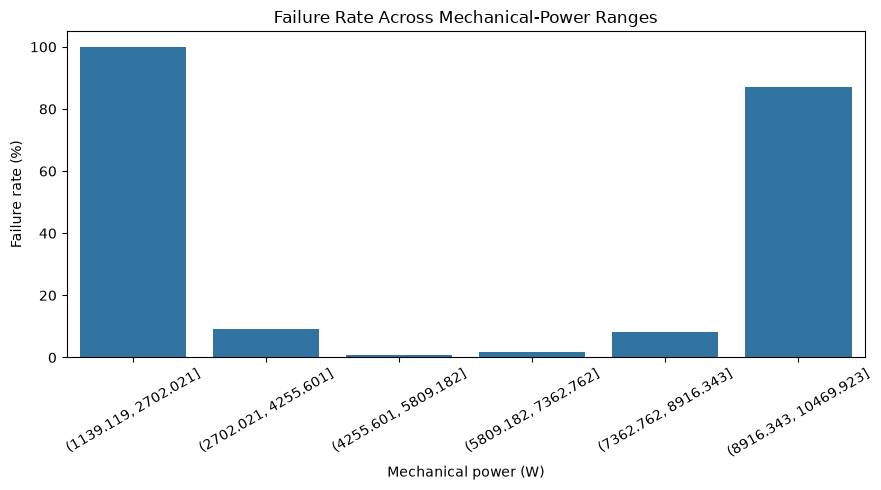

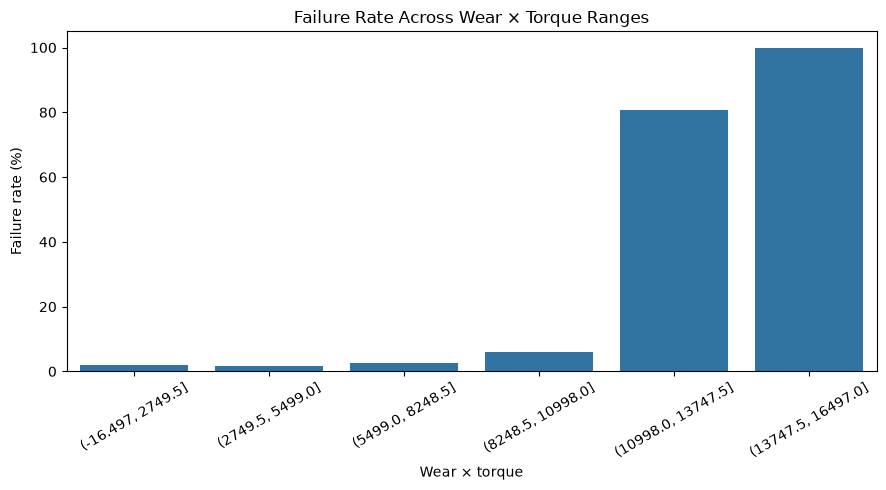

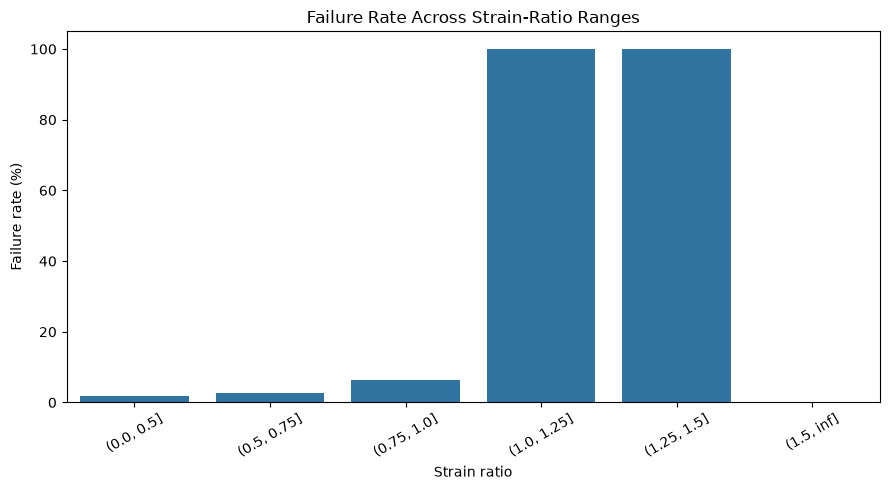

In [25]:
for table, title, xlabel in [
    (temp_failure, "Failure Rate Across Temperature-Difference Ranges", "Temperature difference (K)"),
    (power_failure, "Failure Rate Across Mechanical-Power Ranges", "Mechanical power (W)"),
    (wear_torque_failure, "Failure Rate Across Wear × Torque Ranges", "Wear × torque"),
    (strain_ratio_failure, "Failure Rate Across Strain-Ratio Ranges", "Strain ratio"),
]:
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=table.reset_index(),
        x=table.index.name,
        y="failure_rate",
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Failure rate (%)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 9. Raw vs engineered feature sets

The final model comparison will test both sets empirically.

In [23]:
engineered_model_features = raw_features + [
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

print("RAW FEATURES")
for f in raw_features:
    print(" -", f)

print("\nENGINEERED FEATURES")
for f in engineered_model_features:
    print(" -", f)

RAW FEATURES
 - Type
 - Air temperature [K]
 - Process temperature [K]
 - Rotational speed [rpm]
 - Torque [Nm]
 - Tool wear [min]

ENGINEERED FEATURES
 - Type
 - Air temperature [K]
 - Process temperature [K]
 - Rotational speed [rpm]
 - Torque [Nm]
 - Tool wear [min]
 - temp_diff
 - power_w
 - wear_torque
 - strain_ratio


In [24]:
forbidden_in_engineered = set(engineered_model_features).intersection(
    forbidden_features
)

print("Forbidden columns present in engineered feature set:")
print(forbidden_in_engineered)

assert not forbidden_in_engineered

Forbidden columns present in engineered feature set:
set()


## Conclusion

The notebook defines physically meaningful features from legitimate operating
variables without using identifiers, failure-mode flags or the target.

Whether these features actually improve prediction is intentionally left for the
model-comparison stage.